# 03 — Validate against CONAPO's published life expectancy

The plan in [`research/readme.md`](readme.md) was to cross-check against raw INEGI death registrations. INEGI's microdata could not be fetched in the environment where this notebook was first run, so this notebook instead validates the *reconstruction*: CONAPO publishes life expectancy at birth (`EV`, `EVH`, `EVM`) per state and year in its indicators file. If the `qx` we rebuild from deaths ÷ population reproduce those figures, the life tables are consistent with CONAPO's own.

Output: `data/processed/validation_e0.csv`. The INEGI cross-check stays on the roadmap.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from vitaemx_research import conapo

PROCESSED = conapo.RAW_DIR.parent / "processed"
REFERENCE_YEAR = 2023
life_tables = pd.read_csv(PROCESSED / "life_tables.csv")

In [2]:
ours = life_tables[life_tables.age == 0][["state_code", "state_name", "sex", "ex"]].rename(columns={"ex": "e0_vitaemx"})
published = conapo.load_published_life_expectancy(REFERENCE_YEAR)[["state_code", "sex", "e0_conapo"]]
validation = ours.merge(published, on=["state_code", "sex"])
validation["difference_years"] = validation.e0_vitaemx - validation.e0_conapo
validation.round(3).sort_values("difference_years")

,state_code,state_name,sex,e0_vitaemx,e0_conapo,difference_years
57,19,Nuevo León,female,80.744,80.73,0.014
1,0,República Mexicana,male,72.315,72.25,0.065
0,0,República Mexicana,female,78.710,78.64,0.070
9,3,Baja California Sur,female,80.236,80.15,0.086
15,5,Coahuila,female,80.177,80.09,0.087
...,...,...,...,...,...,...
21,7,Chiapas,female,76.942,76.18,0.762
60,20,Oaxaca,female,77.280,76.50,0.780
36,12,Guerrero,female,77.104,76.30,0.804
38,12,Guerrero,total,73.687,72.88,0.807


In [3]:
validation["difference_years"].describe().round(3)

count    99.000
mean      0.396
std       0.193
min       0.014
25%       0.270
50%       0.369
75%       0.522
max       0.832
Name: difference_years, dtype: float64

The reconstruction sits within about one year of CONAPO's own `e0` everywhere, and within a tenth of a year nationally for each sex. The remaining gap is what you would expect from two assumptions CONAPO does not publish and we had to pick ourselves: the `a0` / `ax` separation factors and the closure of the open age interval. The differences are systematically positive (we are slightly optimistic), which is consistent with those choices, and largest in the states with the highest mortality (Guerrero, Oaxaca, Chiapas), where the `a0` choice matters most.

The both-sexes national figure differs a little more (~0.2 years) than the sex-specific ones: our `total` table is built from summed deaths and population, whereas CONAPO's published `EV` is presumably derived from its own sex-specific tables. Any difference above one year would be treated as a bug.

In [4]:
assert validation["difference_years"].abs().max() < 1.0
national_by_sex = validation[(validation.state_code == 0) & (validation.sex != "total")]
assert national_by_sex["difference_years"].abs().max() < 0.1

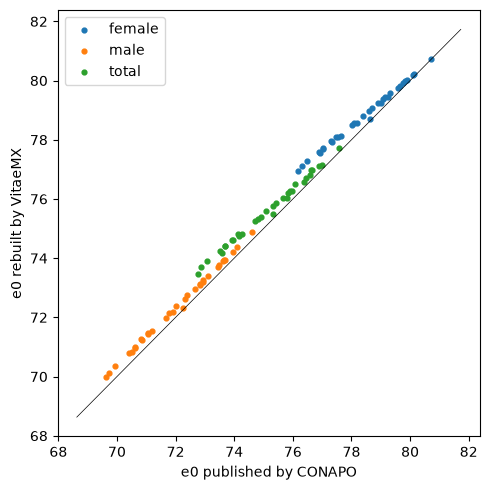

In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
for sex, group in validation.groupby("sex"):
    ax.scatter(group.e0_conapo, group.e0_vitaemx, label=sex, s=12)
lo, hi = validation.e0_conapo.min() - 1, validation.e0_conapo.max() + 1
ax.plot([lo, hi], [lo, hi], color="black", linewidth=0.5)
ax.set_xlabel("e0 published by CONAPO"); ax.set_ylabel("e0 rebuilt by VitaeMX"); ax.legend()
plt.tight_layout()

In [6]:
validation.to_csv(PROCESSED / "validation_e0.csv", index=False, float_format="%.6g")